Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [1]:
from setup import *

In [2]:
# Collision theory 
m_CO = 28.01e-3 / N_A # Mass of CO molecule in kg
P_atm_to_Pa = 101325 # 1 atm to Pa
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
k1_collision = A_site * P_atm_to_Pa / np.sqrt(2*np.pi*m_CO*kb_J*T)
log_k1_collision = np.log(k1_collision)

# Smoluchowski theory
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
k1_smol = 2 * np.pi * diffusion_coefficient * (3e-10) * henry_constant * N_A
log_k1_smol = np.log(k1_smol)

# ER 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.06,63
,3000,0,0.07,63
,3000,0,0.07,7
,3000,0,0.07,39


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2338.08   224.86
p_loo      108.09        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      569   99.0%
   (0.70, 1]   (bad)         2    0.3%
   (1, Inf)   (very bad)    4    0.7%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


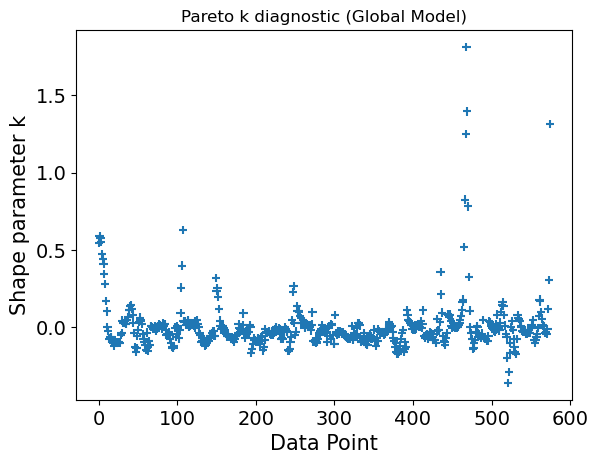

In [ ]:
with pm.Model() as ER_1_2:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.20, sigma=0.2, lower=0) # E_act for breaking solvation cage + Entropy for CO configuration
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.2, lower=0) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_smol - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_k1 + np.log(P_CO_in) - pt.logaddexp(log_k1 - log_K1, log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2, target_accept=0.99)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.479  0.147  -0.751   -0.251      0.004    0.003    1398.0    1763.0    1.0
deltaG4_0  0.063  0.001   0.060    0.065      0.000    0.000    1899.0    2343.0    1.0
beta_2     0.345  0.002   0.342    0.348      0.000    0.000    1301.0    1848.0    1.0
Gact1_0    0.311  0.000   0.311    0.312      0.000    0.000    2446.0    2399.0    1.0
Gact2_0    0.739  0.000   0.739    0.740      0.000    0.000    1396.0    1613.0    1.0


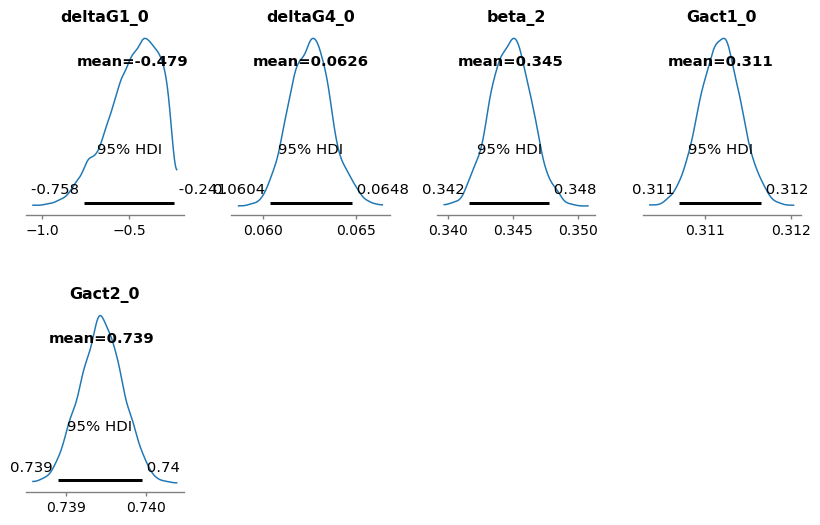

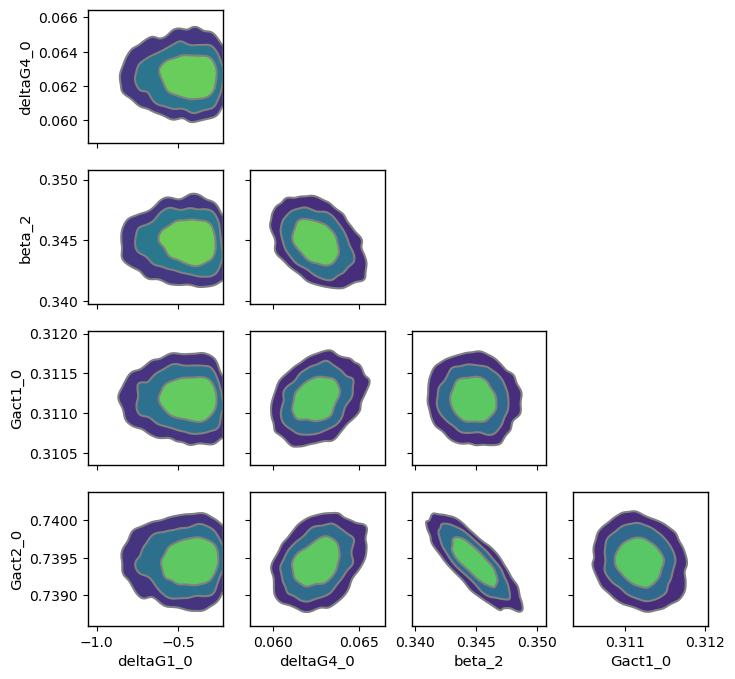

Sampling: [rate]


rate: 0.928


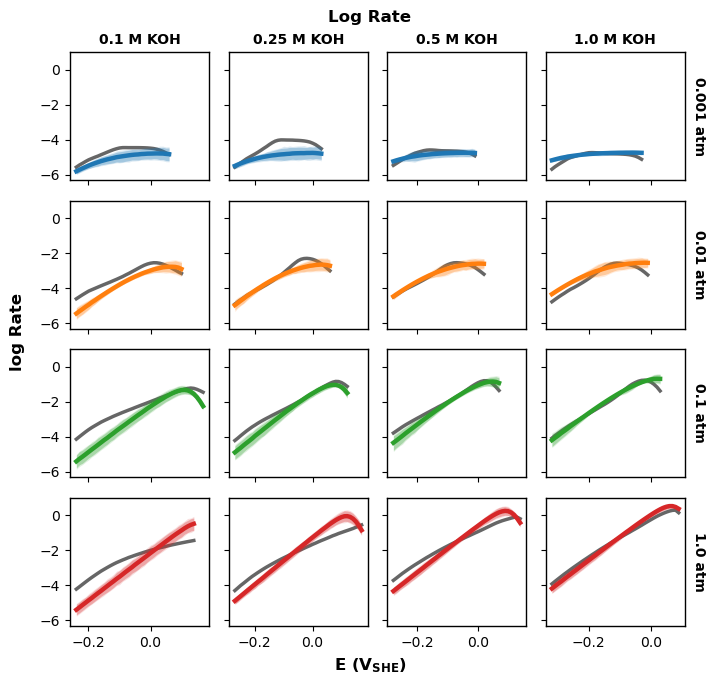

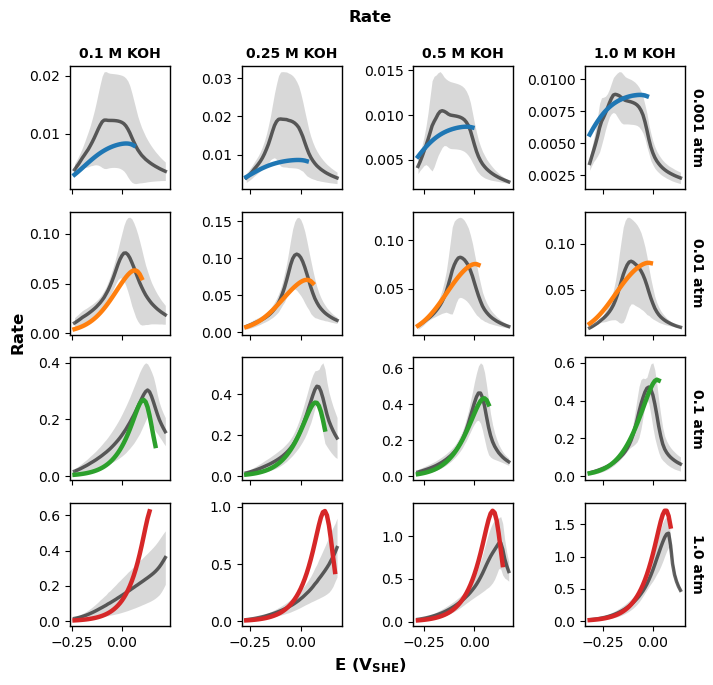

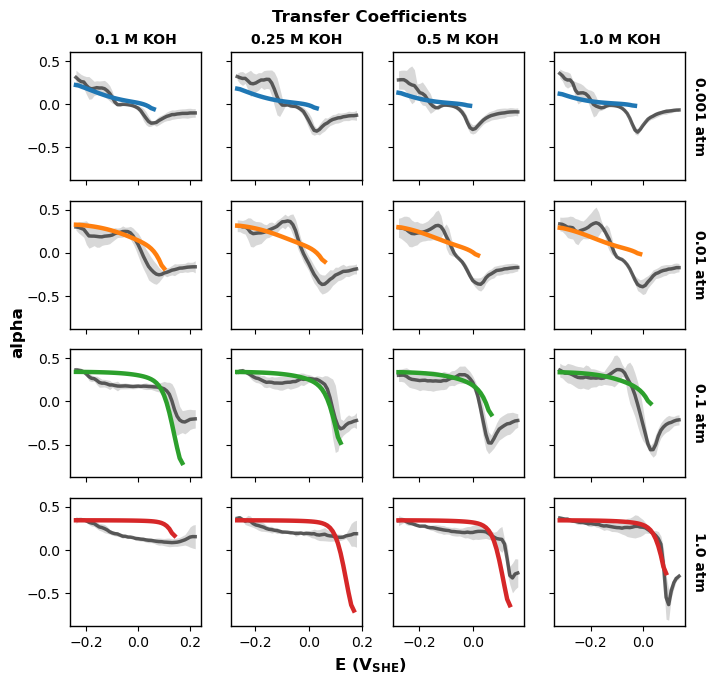

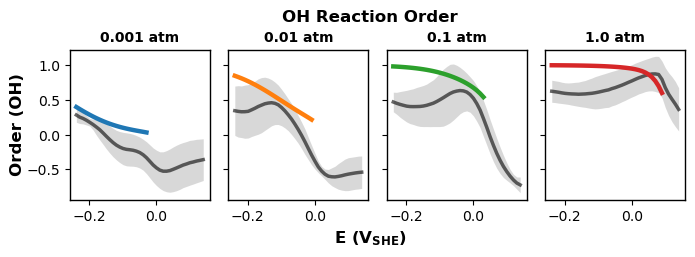

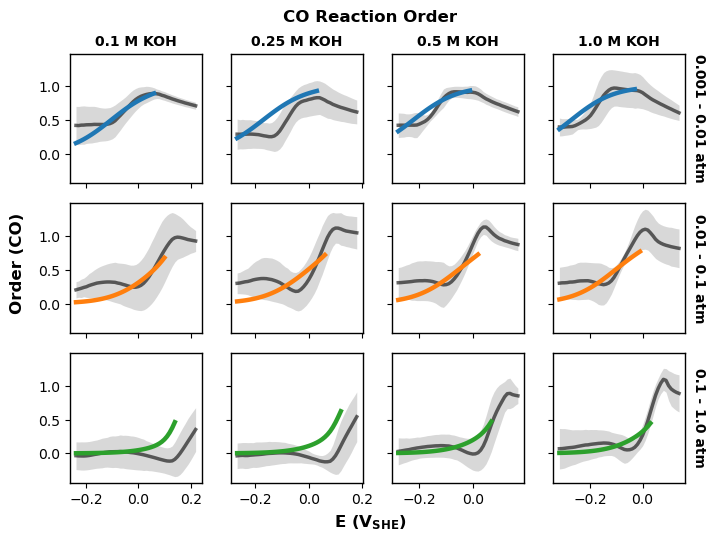

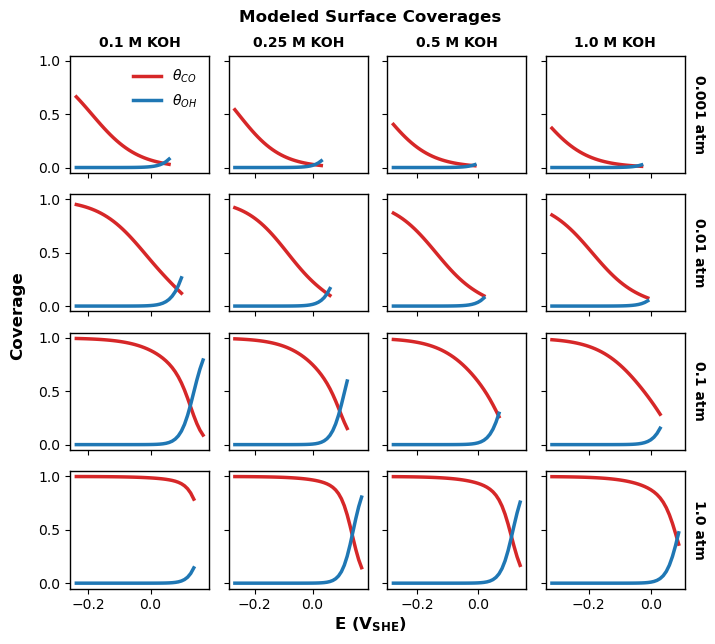

In [15]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2, plot_target)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2); plot_coverages(trace_ER_1_2)

# Comparison

In [7]:
comparison_dict = {
    'ER_1_2': loo_ER_1_2,

}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)